# Footval — Bradley-Terry model diagnostics

These checks tell you **whether to trust the numbers** in `blog_output.ipynb`. The leaderboards
and judge-effect estimates there are summaries of a posterior that was *approximated* by MCMC
(PyMC's NUTS sampler). If the sampler did not explore the posterior well, those summaries are
unreliable no matter how clean they look. This notebook runs the standard **ArviZ** convergence
and sampling diagnostics on the persisted traces in `footval/artifacts/bradley_terry/*.nc`,
for the single judged track (`soundness`).

It is **assessment-only** — it reports no football results, only sampler health.

### The model being checked

Hierarchical Bradley-Terry (`footval/footval/bradley_terry.py`): a latent strength `beta`
per model, plus per-judge **discrimination** (`kappa`), **position / slot-A bias** (`gamma`),
and **self-family preference** (`delta`), with partially-pooled hyperparameters (`mu_*`,
`sigma_*`). Four chains, non-centered parameterization.

### The headline metrics

| Metric | What it measures | Healthy |
|---|---|---|
| **R-hat** | Do the chains agree? (between- vs within-chain variance) | ≤ 1.01 |
| **ESS (bulk)** | Independent-equivalent draws for the posterior body (means) | ≳ 400 |
| **ESS (tail)** | Independent-equivalent draws for the tails (interval edges) | ≳ 400 |
| **Divergences** | NUTS steps that hit unstable geometry it couldn't follow | 0 |
| **BFMI** | How well each chain explores the full energy range / tails | ≳ 0.3 |

**Workflow:** scan the *"at a glance"* table first. If every metric is in range, the plots
below are a confirmation pass and you can trust `blog_output.ipynb`. If a metric trips, the
matching plot tells you *which* parameter failed and *how*.

In [1]:
%matplotlib inline
import warnings

warnings.filterwarnings("ignore")
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display

from footval import bradley_terry as bt
from footval.config import load_config

cfg = load_config()
TRACKS = list(bt.TRACKS)  # one judged criterion -> one track
traces = {t: az.from_netcdf(str(bt.trace_path(cfg, t))) for t in TRACKS}

# variable groups for the plots
BETA = ["beta"]
JUDGE_EFFECTS = ["kappa", "gamma", "delta"]
HYPER = ["mu_gamma", "mu_delta", "sigma_kappa", "sigma_gamma", "sigma_delta"]

{t: dict(traces[t].posterior.sizes) for t in TRACKS}


{'soundness': {'chain': 4, 'draw': 2000, 'judge': 4, 'model': 8}}

## Convergence at a glance

The triage table: **one row per track**, reducing every parameter to its worst value so you can
see in a single look whether anything needs attention. `ok` is `True` only when *all* of the
thresholds below hold.

**How to read each column**

- **`max_r_hat`** — the largest Gelman–Rubin R-hat over all parameters. R-hat compares the
  variance *between* chains to the variance *within* each chain; at convergence the chains are
  interchangeable and R-hat → 1.0. **Look for ≤ 1.01.** Values ≥ 1.05 mean the chains have not
  mixed to a common distribution and the posterior summaries are not yet trustworthy.
- **`min_ess_bulk` / `min_ess_tail`** — the smallest effective sample size across parameters.
  4 chains × 2000 draws = 8000 *correlated* draws; ESS is how many *independent* draws they are
  worth. Bulk ESS governs point estimates (means/medians); tail ESS governs the HDI edges.
  **Look for hundreds-to-thousands** (≳ 400 is the common floor). Low ESS means a summary rests
  on only a handful of effectively-independent samples and will jitter on re-runs.
- **`divergences`** — count of NUTS transitions that diverged (the integrator blew up in a
  region of sharp curvature). **Look for 0.** Even a few can mean a whole region of the
  posterior was never visited, biasing estimates; the usual fixes are a non-centered
  parameterization (already used here) or a higher `target_accept`.
- **`min_bfmi`** — the worst Bayesian Fraction of Missing Information across chains (an
  HMC-specific check, detailed in the Energy section). **Look for ≳ 0.3.**

If `ok` is `True` for every track, the detailed plots are confirmation. If not, use the plots
below to localize the problem to specific parameters and chains.

In [2]:
rows = []
for t in TRACKS:
    idata = traces[t]
    s = az.summary(idata, ci_prob=0.94)
    rhat = s["r_hat"].astype(float)
    ess_bulk = s["ess_bulk"].astype(float)
    ess_tail = s["ess_tail"].astype(float)
    energy = idata.sample_stats["energy"].to_numpy()
    bfmi = np.array([np.sum(np.diff(e) ** 2) / np.sum((e - e.mean()) ** 2) for e in energy])
    n_div = int(idata.sample_stats["diverging"].to_numpy().sum())
    rows.append(
        {
            "track": t,
            "n_params": int(s.shape[0]),
            "max_r_hat": round(float(rhat.max()), 4),
            "min_ess_bulk": round(float(ess_bulk.min()), 0),
            "min_ess_tail": round(float(ess_tail.min()), 0),
            "divergences": n_div,
            "min_bfmi": round(float(bfmi.min()), 3),
            "ok": bool(
                rhat.max() <= 1.01 and ess_bulk.min() >= 400 and n_div == 0 and bfmi.min() >= 0.3
            ),
        }
    )
flags = pl.DataFrame(rows)
flags


track,n_params,max_r_hat,min_ess_bulk,min_ess_tail,divergences,min_bfmi,ok
str,i64,f64,f64,f64,i64,f64,bool
"""soundness""",37,1.0,2931.0,3818.0,0,0.782,true


## Per-parameter summary

The full ArviZ table per track — the same diagnostics as the triage table but **not collapsed**,
so you can see exactly *which* parameter drives any worst-case value, next to its posterior
estimate.

**Columns**

- **`mean`, `sd`** — posterior mean and standard deviation of each parameter.
- **`eti94_lb` / `eti94_ub`** — the 94% credible interval (equal-tailed).
- **`mcse_mean`, `mcse_sd`** — Monte Carlo standard error: the uncertainty in the *estimate of
  the mean / sd* that comes purely from using finitely many MCMC draws. **Rule of thumb:
  `mcse_mean` should be small relative to `sd`** (≪ 10% of it); if it isn't, take more draws
  before quoting that number to many digits.
- **`ess_bulk`, `ess_tail`** — per-parameter effective sample sizes (see above).
- **`r_hat`** — per-parameter convergence (see above).

**How to use it.** Scan the `r_hat` and `ess_*` columns down the table. On this model the
parameters to watch are the variance hyperparameters (`sigma_kappa`, `sigma_gamma`,
`sigma_delta`): with only four judges they are the hardest to estimate, so if anything shows the
lowest ESS or highest R-hat it will usually be one of those. The strengths (`beta`) and the
judge effects should be clean.

In [3]:
for t in TRACKS:
    display(Markdown(f"**Track: `{t}`**"))
    display(az.summary(traces[t], ci_prob=0.94))


**Track: `soundness`**

,mean,sd,eti94_lb,eti94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
z_kappa[claude-fable-5],-0.1,0.87,-1.8,1.6,8984,6081,1.00,0.0092,0.0068
z_kappa[gemini-3.5-flash],0.29,0.9,-1.4,1.9,6283,5855,1.00,0.011,0.0083
z_kappa[glm-5.2],0.29,0.93,-1.5,2,6294,5364,1.00,0.012,0.0088
z_kappa[gpt-5.6-sol],0.19,0.86,-1.5,1.8,8537,5786,1.00,0.0093,0.0071
mu_gamma,0.67,0.224,0.21,1.1,6596,4406,1.00,0.0028,0.0024
z_gamma[claude-fable-5],0.57,0.89,-1.2,2.2,7524,5536,1.00,0.01,0.0076
z_gamma[gemini-3.5-flash],0.26,0.88,-1.5,1.9,7771,5590,1.00,0.01,0.0074
z_gamma[glm-5.2],-0.24,0.87,-1.9,1.4,8170,5818,1.00,0.0096,0.0073
z_gamma[gpt-5.6-sol],0.05,0.86,-1.6,1.7,7865,5732,1.00,0.0097,0.0073
mu_delta,0.636,0.29,0.068,1.2,6456,5365,1.00,0.0036,0.0026


## Trace plots

**Purpose.** The classic visual convergence-and-mixing check: are the four chains sampling the
*same* distribution, and are they moving through it efficiently?

**How to read it.** Each parameter gets two panels:

- *Left (marginal density)* — one curve per chain. The four curves should sit (almost) on top of
  one another. Separated curves mean the chains disagree about where the posterior is.
- *Right (trace)* — the sampled value at each iteration, one colored line per chain. You want a
  stationary, dense band — the proverbial **"fuzzy caterpillar"** — with all chains overlapping
  and rapidly criss-crossing.

**✓ Good signs:** overlapping density curves; traces that look like flat, fuzzy noise with no
trend; chains indistinguishable from one another.

**⚠ Warning signs:** chains exploring different value ranges (non-convergence); slow drift or a
trend across iterations (not yet stationary — needs more tuning/draws); flat stretches where a
chain "sticks" at one value (poor mixing, often near divergences); two or more separated humps in
the density (multimodality the sampler is hopping between).

Shown for the model strengths `beta` and the population hyperparameters.

### `soundness` — strengths (beta)

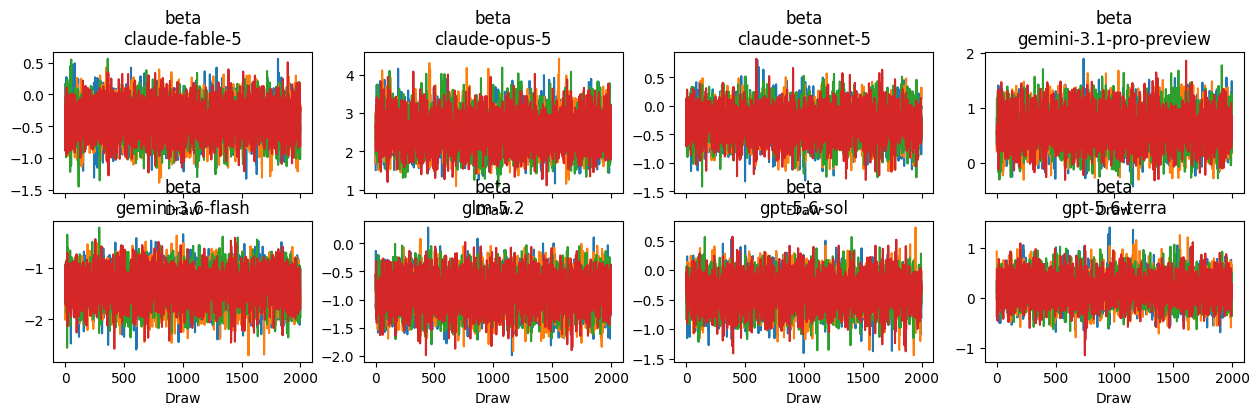

### `soundness` — hyperparameters

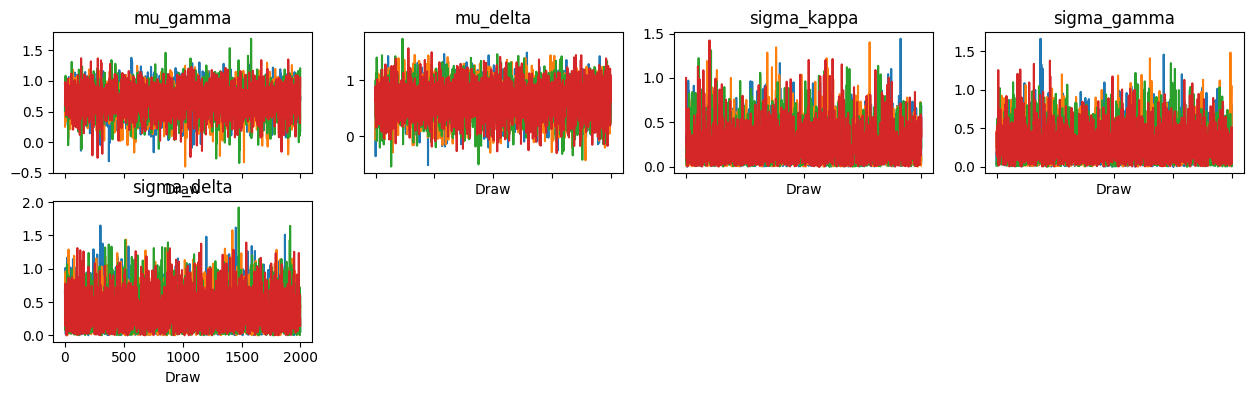

In [4]:
for t in TRACKS:
    display(Markdown(f"### `{t}` — strengths (beta)"))
    az.plot_trace(traces[t], var_names=BETA, backend="matplotlib")
    plt.show()
    display(Markdown(f"### `{t}` — hyperparameters"))
    az.plot_trace(traces[t], var_names=HYPER, backend="matplotlib")
    plt.show()


## Rank plots

**Purpose.** A **more sensitive** between-chain check than the trace plot (Vehtari et al., 2021).
It pools all draws from all chains, converts them to ranks, then histograms the ranks *within
each chain*. If every chain samples the same distribution, each chain's draws are equally likely
to land at any rank, so every chain's histogram should be **flat (uniform)**.

**How to read it.** One panel per chain. The bars should be level — hovering around the uniform
line — with only small random wiggle.

**✓ Good signs:** roughly flat, uniform bars for every chain.

**⚠ Warning signs:** a chain whose bars slope, or are systematically high at one end and low at
the other — that chain is biased toward higher or lower values than the rest, i.e. the chains
have **not** converged to a common distribution. Rank plots catch this even when the trace
"caterpillar" looks fine, which is why they are the preferred modern convergence diagnostic.

Shown for `beta`.

### `soundness` — rank plots (beta)

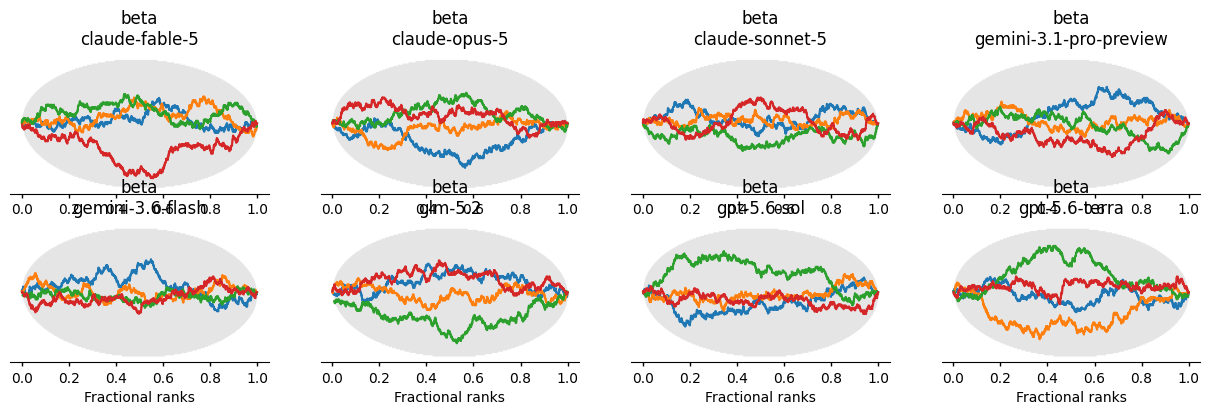

In [5]:
for t in TRACKS:
    display(Markdown(f"### `{t}` — rank plots (beta)"))
    az.plot_rank(traces[t], var_names=BETA, backend="matplotlib")
    plt.show()


## Energy transitions (BFMI)

**Purpose.** An HMC/NUTS-specific check that the sampler can move between the *low-* and
*high-energy* regions of the posterior — i.e. that it actually reaches the tails instead of
getting stuck in the bulk. This is what the **BFMI** (Bayesian Fraction of Missing Information)
number in the triage table measures.

**How to read it.** Two overlaid distributions:

- *marginal energy* — the spread of energies the sampler visited.
- *energy transition* — how much the energy changes between consecutive steps.

The two should have **similar width and overlap closely**. The side panel shows BFMI per chain
against its dashed threshold.

**✓ Good signs:** the two distributions are nearly indistinguishable; BFMI ≳ 0.3.

**⚠ Warning signs:** the transition distribution is much *narrower* than the marginal (BFMI well
below 0.3). That means individual steps can't traverse the full energy range, so the heavy tails
are under-explored — the reported ESS is then optimistic and tail/interval estimates may be
biased. The usual remedy is reparameterization (non-centering, already applied here) or a
different prior scale.

### `soundness` — energy

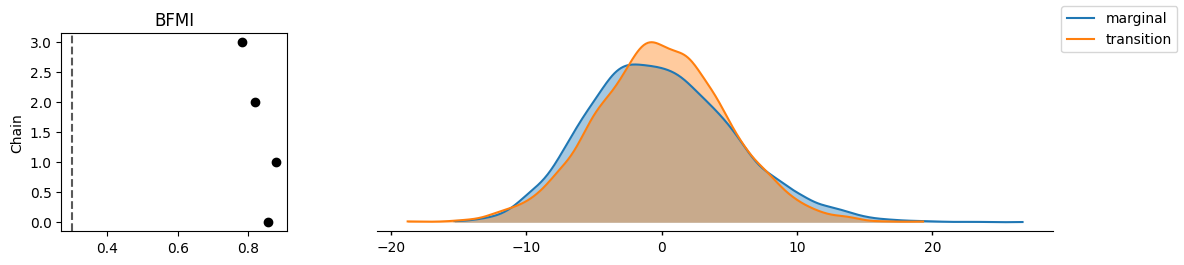

In [6]:
for t in TRACKS:
    display(Markdown(f"### `{t}` — energy"))
    az.plot_energy(traces[t], backend="matplotlib")
    plt.show()


## Forest plots

**Purpose.** Two jobs at once: (1) a compact **convergence check** — each chain's interval is
drawn separately, so you can see whether the chains agree — and (2) a readable **side-by-side
view of the posterior intervals** across many parameters.

**How to read it.** One row per parameter (per chain). The dot is the point estimate; the line is
the credible interval. `beta` is on the sum-to-zero strength scale (0 ≈ an average model). The
judge effects are `kappa` (discrimination; >1 = sharper-than-average judge), `gamma` (position /
slot-A bias; >0 favors whichever answer is shown first), and `delta` (self-family preference; >0
means a judge favors its own family).

**✓ Good signs:** the per-chain intervals for each parameter line up on top of each other; widths
are sensible (not collapsed to a point, not absurdly wide).

**⚠ Warning signs:** a parameter whose chains are visibly offset from one another (a convergence
problem, corroborating R-hat). Substantively, keep the caveat in mind: with only **four judges**
the `kappa` / `gamma` / `delta` intervals are wide — read them as directional, not precise.

### `soundness` — strengths (beta)

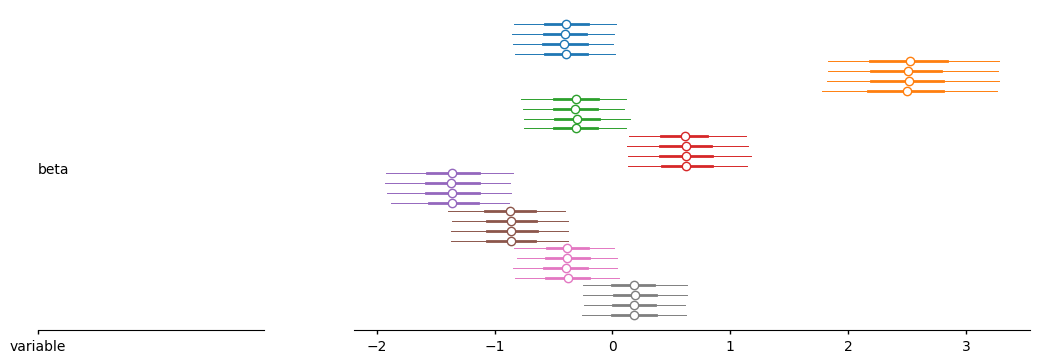

### `soundness` — judge effects

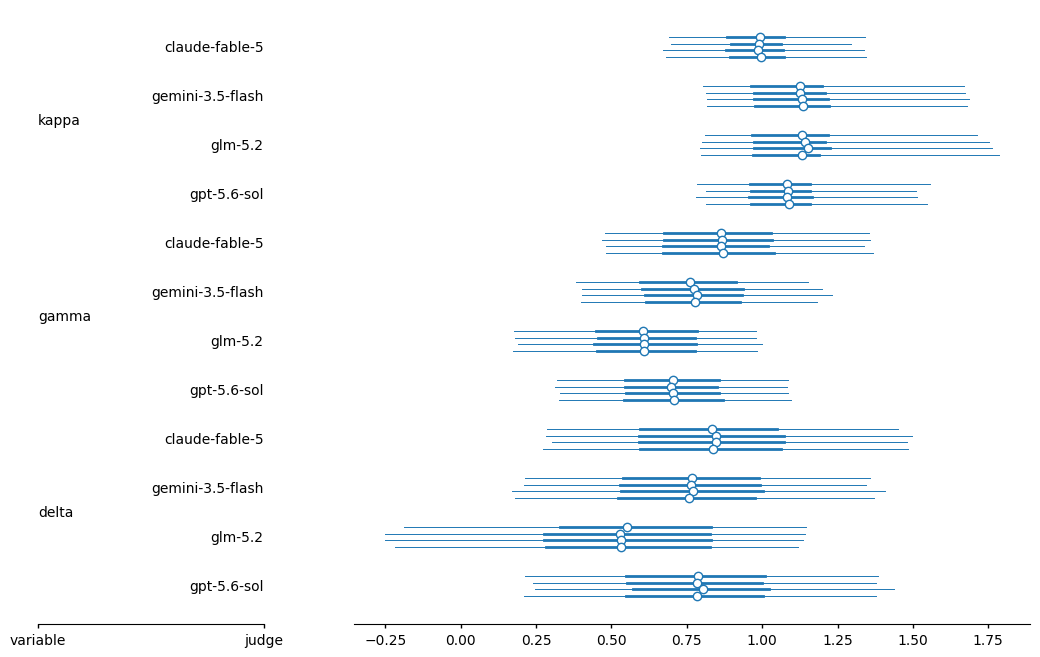

In [7]:
for t in TRACKS:
    display(Markdown(f"### `{t}` — strengths (beta)"))
    az.plot_forest(traces[t], var_names=BETA, backend="matplotlib")
    plt.show()
    display(Markdown(f"### `{t}` — judge effects"))
    az.plot_forest(traces[t], var_names=JUDGE_EFFECTS, backend="matplotlib")
    plt.show()


## Effective sample size across the distribution

**Purpose.** The triage table reports only the *minimum* ESS; this plot shows ESS as a function
of position in the distribution, so you can confirm the sample is informative **everywhere** —
not just on average, and especially out in the tails, which set the HDI edges you publish.

**How to read it.** For each parameter, ESS is plotted across a series of quantiles (the small
and large quantiles are the tails). Higher is better; the dashed line marks the rule-of-thumb
floor (~400).

**✓ Good signs:** ESS sits well above the floor across all quantiles, including the extremes.

**⚠ Warning signs:** ESS that dips toward (or below) the floor — especially at the low / high
quantiles. Low *tail* ESS means the 50% / 95% interval endpoints in the leaderboards are the
noisiest part of the estimate and could shift on a re-run; the fix is simply more draws.

Shown for `beta`.

### `soundness` — ESS (beta)

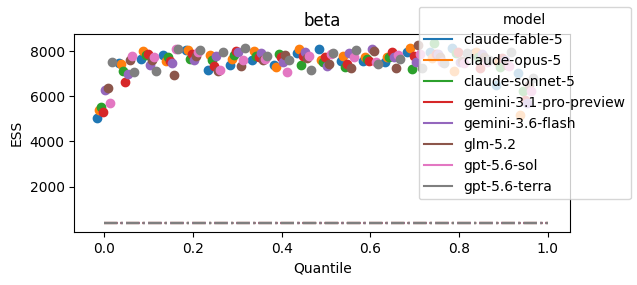

In [8]:
for t in TRACKS:
    display(Markdown(f"### `{t}` — ESS (beta)"))
    az.plot_ess(traces[t], var_names=BETA, backend="matplotlib")
    plt.show()
